In [39]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import trimesh
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

REGION_FILES = {
    "foot1": Path("Adhension1.STL"),
    "foot2": Path("Adhension2.STL"),
}

def load_stl(path: Path) -> trimesh.Trimesh:
    if not path.exists():
        raise FileNotFoundError(
            f"找不到文件：{path.resolve()}"
        )

    mesh = trimesh.load_mesh(
        str(path),
        force="mesh",
        process=True,
    )
    if not isinstance(mesh, trimesh.Trimesh):
        raise TypeError(
            f"{path.name} 没有被读取为三角网格"
        )

    if len(mesh.faces) == 0:
        raise ValueError(
            f"{path.name} 中没有三角面"
        )

    mesh.remove_unreferenced_vertices

    return mesh

meshes = {}

for name, path in REGION_FILES.items():
    mesh = load_stl(path)
    meshes[name] = mesh

    print(f"\n========== {name} ==========")
    print("文件：", path.resolve())
    print("顶点数量：", len(mesh.vertices))
    print("三角面数量：", len(mesh.faces))
    print("包围盒尺寸：", mesh.extents)
    print("是否封闭：", mesh.is_watertight)



========== foot1 ==========
文件： /home/song/projects/climbrobo/Adhension1.STL
顶点数量： 3111
三角面数量： 6422
包围盒尺寸： [1.00000009e-03 1.39999992e-01 3.79234839e+01]
是否封闭： True

========== foot2 ==========
文件： /home/song/projects/climbrobo/Adhension2.STL
顶点数量： 3332
三角面数量： 6868
包围盒尺寸： [1.40000347e-01 1.00000009e-03 3.79234839e+01]
是否封闭： True


In [40]:
# =========================================================
# 第二段：寻找每个薄层的两个主平面及其法向
# =========================================================

# 允许三角面法向存在3°以内的误差
ANGLE_TOLERANCE_DEG = 3.0


def normalize(vector: np.ndarray) -> np.ndarray:
    """
    将一个向量变成长度为1的单位向量。
    向量方向保持不变。
    """
    length = np.linalg.norm(vector)

    if length < 1e-12:
        raise ValueError("无法归一化长度接近0的向量")

    return vector / length


def weighted_center(
    face_indices: np.ndarray,
    face_centers: np.ndarray,
    face_areas: np.ndarray,
) -> np.ndarray:
    """
    根据三角面面积计算一组面的加权中心。
    面积越大的三角面，对中心位置影响越大。
    """
    return np.average(
        face_centers[face_indices],
        axis=0,
        weights=face_areas[face_indices],
    )


def find_two_main_faces(
    mesh: trimesh.Trimesh,
) -> dict:
    """
    从一个薄层实体中找出两个面积最大的平行面。

    返回：
    - A面的三角面编号
    - B面的三角面编号
    - 两个面的中心
    - 两个面的外法向
    - 两个面的面积
    - 薄层厚度
    """

    # 每个三角面的法向
    face_normals = np.asarray(
        mesh.face_normals
    )

    # 每个三角面的面积
    face_areas = np.asarray(
        mesh.area_faces
    )

    # 每个三角面的中心点
    face_centers = np.asarray(
        mesh.triangles_center
    )

    # 将允许角度转换成点积阈值
    cosine_threshold = np.cos(
        np.deg2rad(ANGLE_TOLERANCE_DEG)
    )

    # -----------------------------------------------------
    # 找薄层两个大面的共同法向方向
    # -----------------------------------------------------

    best_axis = None
    best_parallel_area = -1.0

    # 按三角面面积从大到小排列
    sorted_faces = np.argsort(
        face_areas
    )[::-1]

    # 最多检查面积最大的500个三角面
    candidate_faces = sorted_faces[
        :min(500, len(sorted_faces))
    ]

    for face_index in candidate_faces:

        candidate_axis = normalize(
            face_normals[face_index]
        )

        # 计算其他面法向与当前法向的平行程度
        alignment = np.abs(
            face_normals @ candidate_axis
        )

        # 找到与当前方向平行或反平行的三角面
        parallel_mask = (
            alignment >= cosine_threshold
        )

        # 累计这些平行三角面的面积
        parallel_area = face_areas[
            parallel_mask
        ].sum()

        if parallel_area > best_parallel_area:
            best_parallel_area = parallel_area
            best_axis = candidate_axis

    if best_axis is None:
        raise RuntimeError(
            "没有找到薄层主平面方向"
        )

    best_axis = normalize(best_axis)

    # -----------------------------------------------------
    # 找出所有与主平面方向平行的三角面
    # -----------------------------------------------------

    alignment = np.abs(
        face_normals @ best_axis
    )

    parallel_faces = np.where(
        alignment >= cosine_threshold
    )[0]

    if len(parallel_faces) < 2:
        raise RuntimeError(
            "找到的平行三角面数量不足"
        )

    # 每个三角面中心沿厚度方向的位置
    plane_positions = (
        face_centers[parallel_faces]
        @ best_axis
    )

    min_position = plane_positions.min()
    max_position = plane_positions.max()

    middle_position = (
        min_position + max_position
    ) / 2.0

    # -----------------------------------------------------
    # 根据厚度方向的位置分成A面和B面
    # -----------------------------------------------------

    face_a_indices = parallel_faces[
        plane_positions <= middle_position
    ]

    face_b_indices = parallel_faces[
        plane_positions > middle_position
    ]

    if len(face_a_indices) == 0:
        raise RuntimeError("A面为空")

    if len(face_b_indices) == 0:
        raise RuntimeError("B面为空")

    # 两个面的面积加权中心
    center_a = weighted_center(
        face_a_indices,
        face_centers,
        face_areas,
    )

    center_b = weighted_center(
        face_b_indices,
        face_centers,
        face_areas,
    )

    # 薄层中间位置
    middle_center = (
        center_a + center_b
    ) / 2.0

    # A面法向从薄层内部指向A面外部
    normal_a = normalize(
        center_a - middle_center
    )

    # B面法向从薄层内部指向B面外部
    normal_b = normalize(
        center_b - middle_center
    )

    # 计算两个面的总面积
    area_a = face_areas[
        face_a_indices
    ].sum()

    area_b = face_areas[
        face_b_indices
    ].sum()

    # 两个大面之间的距离，即薄层厚度
    thickness = (
        max_position - min_position
    )

    return {
        "face_a_indices": face_a_indices,
        "face_b_indices": face_b_indices,
        "center_a": center_a,
        "center_b": center_b,
        "normal_a": normal_a,
        "normal_b": normal_b,
        "area_a": area_a,
        "area_b": area_b,
        "thickness": thickness,
    }

In [41]:
surface_data = {}

for name, mesh in meshes.items():

    data = find_two_main_faces(mesh)

    surface_data[name] = data

    print(f"\n========== {name} ==========")

    print("A面三角面数量：",
          len(data["face_a_indices"]))

    print("B面三角面数量：",
          len(data["face_b_indices"]))

    print("A面中心：",
          data["center_a"])

    print("A面法向：",
          data["normal_a"])

    print("A面面积：",
          data["area_a"])

    print("B面中心：",
          data["center_b"])

    print("B面法向：",
          data["normal_b"])

    print("B面面积：",
          data["area_b"])

    print(
        "两个法向的点积：",
        np.dot(
            data["normal_a"],
            data["normal_b"],
        ),
    )

    print(
        "薄层厚度：",
        data["thickness"],
        "m"
    )

    print(
        "薄层厚度约：",
        data["thickness"] * 1000,
        "mm"
    )


========== foot1 ==========
A面三角面数量： 1689
B面三角面数量： 1690
A面中心： [-1.00000005e-03  7.05687950e-02  1.90752765e+01]
A面法向： [-9.99999996e-01 -7.26457711e-08 -9.07119978e-05]
A面面积： 4.700063292664899
B面中心： [4.74980055e-11 7.05687951e-02 1.90752766e+01]
B面法向： [9.99999996e-01 7.26457433e-08 9.07119907e-05]
B面面积： 4.700063338624232
两个法向的点积： -1.0000000000000002
薄层厚度： 0.0010000000949954568 m
薄层厚度约： 1.0000000949954568 mm

========== foot2 ==========
A面三角面数量： 1806
B面三角面数量： 1806
A面中心： [7.05211303e-02 4.74975614e-11 1.90518195e+01]
A面法向： [-2.77555730e-14  1.00000000e+00 -7.10542668e-12]
A面面积： 4.691879700428243
B面中心： [ 7.05211303e-02 -1.00000005e-03  1.90518195e+01]
B面法向： [ 2.77555730e-14 -1.00000000e+00  1.42108534e-11]
B面面积： 4.6918797004282435
两个法向的点积： -1.0
薄层厚度： 0.0010000000949950127 m
薄层厚度约： 1.0000000949950127 mm



整体坐标范围：
最小坐标： [-1.00000005e-03 -1.00000005e-03  8.86968337e-07]
最大坐标： [ 0.14        0.13999996 37.9234848 ]
三个方向尺寸： [ 0.141       0.14099996 37.92348392]
自动判定最长方向： Z
Z方向完整长度： 37.92348391527776
Z方向显示长度： 0.25380000115837903

局部放大图片已保存： /home/song/projects/climbrobo/two_adsorb_faces_zoomed.png


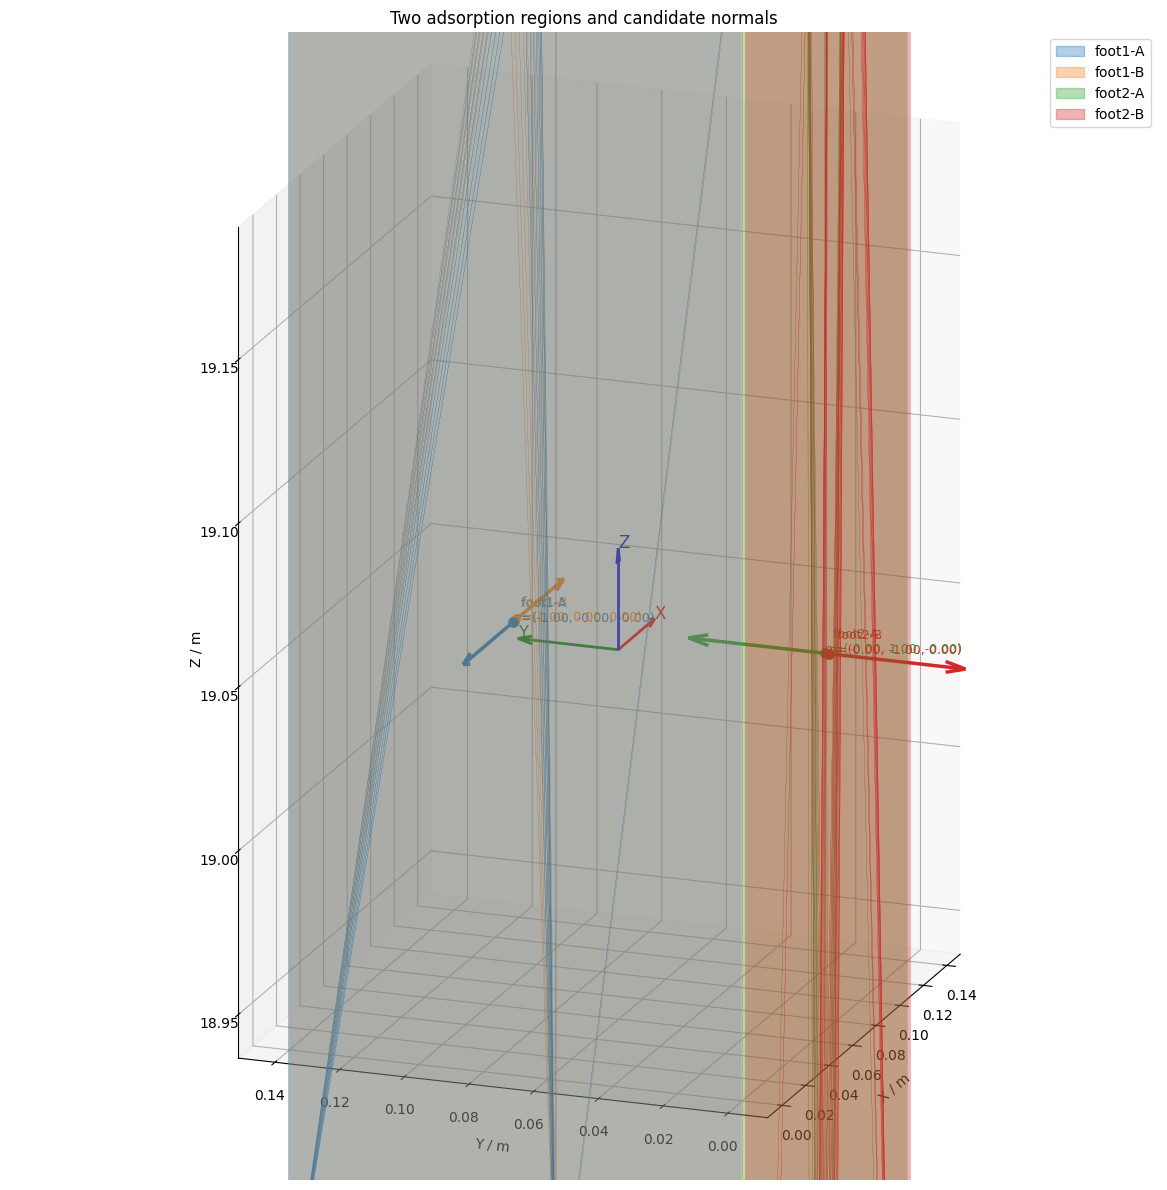

In [42]:
# =========================================================
# 第三段：局部放大显示两个附着区域及其法向
# =========================================================

# 沿模型最长方向显示多长。
# 1.8表示显示长度约为模型横向宽度的1.8倍。
# 数值越小，局部放得越大。
LONG_WINDOW_WIDTH_RATIO = 1.8

# 非最长方向保留的边缘空白
WIDTH_MARGIN_RATIO = 0.08

# 法向箭头长度相对于横向宽度的比例
NORMAL_ARROW_RATIO = 0.30


# ---------------------------------------------------------
# 收集两个附着区域的整体坐标范围
# ---------------------------------------------------------

all_vertices = np.vstack(
    [
        mesh.vertices
        for mesh in meshes.values()
    ]
)

global_min = all_vertices.min(axis=0)
global_max = all_vertices.max(axis=0)
global_extent = global_max - global_min

print("\n整体坐标范围：")
print("最小坐标：", global_min)
print("最大坐标：", global_max)
print("三个方向尺寸：", global_extent)


# ---------------------------------------------------------
# 自动判断哪个方向最长
# ---------------------------------------------------------

long_axis = int(
    np.argmax(global_extent)
)

axis_names = ["X", "Y", "Z"]

other_axes = [
    axis
    for axis in range(3)
    if axis != long_axis
]

print(
    "自动判定最长方向：",
    axis_names[long_axis],
)


# 两个横向方向中的较大尺寸
transverse_size = max(
    global_extent[other_axes[0]],
    global_extent[other_axes[1]],
)

if transverse_size < 1e-12:
    raise RuntimeError(
        "附着区域横向尺寸接近0，无法设置显示范围"
    )


# ---------------------------------------------------------
# 收集4个候选面的中心
# ---------------------------------------------------------

face_centers_for_view = []

for region_name in ["foot1", "foot2"]:

    data = surface_data[region_name]

    face_centers_for_view.append(
        data["center_a"]
    )

    face_centers_for_view.append(
        data["center_b"]
    )

face_centers_for_view = np.asarray(
    face_centers_for_view
)


# 以4个候选面的平均位置作为局部显示中心
view_center = face_centers_for_view.mean(
    axis=0
)

# 4个候选面中心沿最长方向的跨度
center_long_min = face_centers_for_view[
    :, long_axis
].min()

center_long_max = face_centers_for_view[
    :, long_axis
].max()

center_long_span = (
    center_long_max - center_long_min
)


# ---------------------------------------------------------
# 设置最长方向的局部显示长度
# ---------------------------------------------------------

# 根据模型宽度确定局部窗口
long_window_size = (
    transverse_size
    * LONG_WINDOW_WIDTH_RATIO
)

# 确保foot1和foot2的中心都在画面中
required_center_size = (
    center_long_span
    + transverse_size * 0.4
)

long_window_size = max(
    long_window_size,
    required_center_size,
)

# 不超过模型本身的完整长度
long_window_size = min(
    long_window_size,
    global_extent[long_axis],
)


# 最长方向显示范围
long_min = (
    view_center[long_axis]
    - long_window_size / 2
)

long_max = (
    view_center[long_axis]
    + long_window_size / 2
)


# 防止显示范围超出模型整体范围
if long_min < global_min[long_axis]:

    shift = (
        global_min[long_axis]
        - long_min
    )

    long_min += shift
    long_max += shift


if long_max > global_max[long_axis]:

    shift = (
        long_max
        - global_max[long_axis]
    )

    long_min -= shift
    long_max -= shift


print(
    f"{axis_names[long_axis]}方向完整长度：",
    global_extent[long_axis],
)

print(
    f"{axis_names[long_axis]}方向显示长度：",
    long_window_size,
)


# ---------------------------------------------------------
# 建立图像
# ---------------------------------------------------------

fig = plt.figure(
    figsize=(16, 12),
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

# 使用正交投影，减少透视变形
ax.set_proj_type("ortho")


color_map = {
    ("foot1", "A"): "tab:blue",
    ("foot1", "B"): "tab:orange",
    ("foot2", "A"): "tab:green",
    ("foot2", "B"): "tab:red",
}

legend_handles = []


# 法向箭头长度根据横向宽度确定
arrow_length = (
    transverse_size
    * NORMAL_ARROW_RATIO
)


# ---------------------------------------------------------
# 绘制4个候选面及法向
# ---------------------------------------------------------

for region_name in ["foot1", "foot2"]:

    mesh = meshes[region_name]
    data = surface_data[region_name]

    for side in ["A", "B"]:

        if side == "A":

            face_indices = data[
                "face_a_indices"
            ]

            center = data[
                "center_a"
            ]

            normal = data[
                "normal_a"
            ]

        else:

            face_indices = data[
                "face_b_indices"
            ]

            center = data[
                "center_b"
            ]

            normal = data[
                "normal_b"
            ]

        triangles = mesh.triangles[
            face_indices
        ]

        color = color_map[
            (region_name, side)
        ]

        # 绘制候选面
        surface_collection = Poly3DCollection(
            triangles,
            facecolor=color,
            edgecolor=color,
            alpha=0.35,
            linewidth=0.15,
        )

        ax.add_collection3d(
            surface_collection
        )

        # 绘制面中心
        ax.scatter(
            center[0],
            center[1],
            center[2],
            s=45,
            color=color,
        )

        # 绘制法向
        ax.quiver(
            center[0],
            center[1],
            center[2],
            normal[0],
            normal[1],
            normal[2],
            length=arrow_length,
            normalize=True,
            color=color,
            linewidth=2.5,
            arrow_length_ratio=0.15,
        )

        # 标注面名称和法向数值
        label = (
            f"{region_name}-{side}\n"
            f"n=({normal[0]:.2f}, "
            f"{normal[1]:.2f}, "
            f"{normal[2]:.2f})"
        )

        ax.text(
            center[0],
            center[1],
            center[2],
            "  " + label,
            fontsize=9,
            color=color,
        )

        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor=color,
                alpha=0.35,
                label=f"{region_name}-{side}",
            )
        )


# ---------------------------------------------------------
# 设置三个方向的显示范围
# ---------------------------------------------------------

axis_limits = []

for axis in range(3):

    if axis == long_axis:

        # 最长方向只显示中心附近的一段
        axis_limits.append(
            (long_min, long_max)
        )

    else:

        # 横向方向完整显示，并留少量边缘
        margin = (
            global_extent[axis]
            * WIDTH_MARGIN_RATIO
        )

        if margin < transverse_size * 0.02:
            margin = transverse_size * 0.02

        axis_limits.append(
            (
                global_min[axis] - margin,
                global_max[axis] + margin,
            )
        )


ax.set_xlim(
    axis_limits[0][0],
    axis_limits[0][1],
)

ax.set_ylim(
    axis_limits[1][0],
    axis_limits[1][1],
)

ax.set_zlim(
    axis_limits[2][0],
    axis_limits[2][1],
)


# ---------------------------------------------------------
# 设置显示框比例
# ---------------------------------------------------------

display_extent = np.array(
    [
        axis_limits[0][1] - axis_limits[0][0],
        axis_limits[1][1] - axis_limits[1][0],
        axis_limits[2][1] - axis_limits[2][0],
    ]
)

# 按当前局部窗口设置比例，
# 不再由完整模型的超长尺寸控制画面
ax.set_box_aspect(
    display_extent
)


# ---------------------------------------------------------
# 在当前局部画面角落绘制全局XYZ方向
# ---------------------------------------------------------

coordinate_origin = np.array(
    [
        axis_limits[0][0],
        axis_limits[1][0],
        axis_limits[2][0],
    ],
    dtype=float,
)

coordinate_origin += (
    display_extent * 0.08
)

coordinate_axis_length = (
    transverse_size * 0.22
)

axis_directions = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.0, 1.0]),
]

axis_colors = [
    "r",
    "g",
    "b",
]

for direction, color, axis_name in zip(
    axis_directions,
    axis_colors,
    axis_names,
):

    ax.quiver(
        coordinate_origin[0],
        coordinate_origin[1],
        coordinate_origin[2],
        direction[0],
        direction[1],
        direction[2],
        length=coordinate_axis_length,
        normalize=True,
        color=color,
        linewidth=2,
        arrow_length_ratio=0.15,
    )

    text_position = (
        coordinate_origin
        + direction
        * coordinate_axis_length
    )

    ax.text(
        text_position[0],
        text_position[1],
        text_position[2],
        axis_name,
        color=color,
        fontsize=12,
    )


# ---------------------------------------------------------
# 图形设置
# ---------------------------------------------------------

ax.set_xlabel("X / m")
ax.set_ylabel("Y / m")
ax.set_zlabel("Z / m")

ax.set_title(
    "Two adsorption regions and candidate normals"
)

ax.legend(
    handles=legend_handles,
    loc="upper right",
)

# 初始观察角度
ax.view_init(
    elev=18,
    azim=-160,
)

plt.tight_layout()

output_path = Path(
    "two_adsorb_faces_zoomed.png"
)

plt.savefig(
    output_path,
    dpi=250,
    bbox_inches="tight",
    pad_inches=0.05,
)

print(
    "\n局部放大图片已保存：",
    output_path.resolve(),
)

plt.show()

In [43]:
# =========================================================
# 第四段：确定最终附着面，并建立局部二维坐标系
# =========================================================

selected_surface = {
    "foot1": {
        # 几何面选 B
        "face_indices": surface_data["foot1"]["face_b_indices"],
        "center": surface_data["foot1"]["center_b"],
        # 法向取 A 的方向，即从附着面指向机器人
        "normal": surface_data["foot1"]["normal_a"],
    },
    "foot2": {
        "face_indices": surface_data["foot2"]["face_a_indices"],
        "center": surface_data["foot2"]["center_a"],
        "normal": surface_data["foot2"]["normal_b"],
    },
}

In [44]:
def project_to_plane(
    points: np.ndarray,
    plane_origin: np.ndarray,
    plane_normal: np.ndarray,
) -> np.ndarray:
    """
    将点正交投影到指定平面上。
    """
    relative = points - plane_origin
    distance = relative @ plane_normal
    projected = points - distance[:, None] * plane_normal[None, :]
    return projected
    #@为点乘，平面远点与平面法相，  

def build_local_frame(
    mesh: trimesh.Trimesh,
    face_indices: np.ndarray,
    center: np.ndarray,
    normal: np.ndarray,
) -> dict:
    """
    根据一个附着面的三角面，建立局部二维坐标系：
    O: 原点（附着面中心）
    U: 面内第一方向
    V: 面内第二方向
    N: 法向（已指定为朝机器人）
    """

    # 取出该面的所有三角形顶点
    triangles = mesh.triangles[face_indices]
    points = triangles.reshape(-1, 3)

    # 去重，避免同一个顶点重复太多次
    points = np.unique(
        np.round(points, decimals=10),
        axis=0,
    )

    # 投影到附着面平面上
    projected_points = project_to_plane(
        points=points,
        plane_origin=center,
        plane_normal=normal,
    )

    # 以中心为原点做SVD，找平面内主方向
    centered_points = projected_points - center

    _, _, vh = np.linalg.svd(
        centered_points,
        full_matrices=False,
    )

    # SVD的第一主方向作为U
    u_axis = normalize(vh[0])

    # 如果u_axis和法向不够正交，就改用第二主方向
    if abs(np.dot(u_axis, normal)) > 1e-3:
        u_axis = normalize(vh[1])

    # 用叉乘得到V，保证 U、V、N 构成右手系
    v_axis = normalize(
        np.cross(normal, u_axis)
    )

    # 再用一次叉乘修正U，保证完全正交
    u_axis = normalize(
        np.cross(v_axis, normal)
    )

    return {
        "origin": center,
        "u_axis": u_axis,
        "v_axis": v_axis,
        "normal": normal,
        "points_3d": projected_points,
    }

In [45]:
local_frames = {}

for name in ["foot1", "foot2"]:
    mesh = meshes[name]
    surface = selected_surface[name]

    frame = build_local_frame(
        mesh=mesh,
        face_indices=surface["face_indices"],
        center=surface["center"],
        normal=surface["normal"],
    )

    local_frames[name] = frame

    print(f"\n========== {name} 局部坐标系 ==========")
    print("原点 O：", frame["origin"])
    print("U 轴：", frame["u_axis"])
    print("V 轴：", frame["v_axis"])
    print("N 轴：", frame["normal"])

    print("U·V =", np.dot(frame["u_axis"], frame["v_axis"]))
    print("U·N =", np.dot(frame["u_axis"], frame["normal"]))
    print("V·N =", np.dot(frame["v_axis"], frame["normal"]))


========== foot1 局部坐标系 ==========
原点 O： [4.74980055e-11 7.05687951e-02 1.90752766e+01]
U 轴： [-9.07119975e-05 -4.25810931e-06  9.99999996e-01]
V 轴： [-7.30320324e-08  1.00000000e+00  4.25810271e-06]
N 轴： [-9.99999996e-01 -7.26457711e-08 -9.07119978e-05]
U·V = 2.1005711460851593e-23
U·N = 3.492420358043747e-21
V·N = 7.361531557088649e-24

========== foot2 局部坐标系 ==========
原点 O： [7.05211303e-02 4.74975614e-11 1.90518195e+01]
U 轴： [2.04129236e-05 1.42108539e-11 1.00000000e+00]
V 轴： [-1.00000000e+00 -2.74654879e-14  2.04129236e-05]
N 轴： [ 2.77555730e-14 -1.00000000e+00  1.42108534e-11]
U·V = 1.4705631710403238e-21
U·N = -2.867241835715532e-28
V·N = 5.17487950907643e-31


In [46]:
# =========================================================
# 第五段：将选定附着面投影到二维，并重建二维轮廓
# =========================================================

from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
from shapely.ops import unary_union


def xyz_to_uv(
    points_xyz: np.ndarray,
    origin: np.ndarray,
    u_axis: np.ndarray,
    v_axis: np.ndarray,
) -> np.ndarray:
    """
    将三维点转换为附着面局部二维坐标 (u, v)。

    points_xyz:
        形状可以是 (N, 3)

    返回：
        形状为 (N, 2)
    """

    # 每个点相对于局部坐标原点O的位置
    relative = points_xyz - origin

    # 分别投影到局部U轴、V轴
    u_coordinate = relative @ u_axis
    v_coordinate = relative @ v_axis

    points_uv = np.column_stack(
        (
            u_coordinate,
            v_coordinate,
        )
    )

    return points_uv

In [47]:
def build_uv_region(
    mesh: trimesh.Trimesh,
    face_indices: np.ndarray,
    frame: dict,
):
    """
    将选定附着面的所有三角形投影到二维，
    再把二维三角形合并成完整附着区域。

    返回：
        region_uv：
            Shapely二维区域

        triangles_uv：
            每个三角形的二维坐标，用于检查投影网格
    """

    # 取出选定B面的所有三角形
    triangles_xyz = mesh.triangles[
        face_indices
    ]

    # 原始形状为：
    # (三角形数量, 3个顶点, 3维坐标)
    triangle_count = triangles_xyz.shape[0]

    # 先拉平成所有三维顶点
    points_xyz = triangles_xyz.reshape(
        -1,
        3,
    )

    # 为消除浮点误差，先正交投影回理想平面
    points_projected = project_to_plane(
        points=points_xyz,
        plane_origin=frame["origin"],
        plane_normal=frame["normal"],
    )

    # 转换为二维(u, v)
    points_uv = xyz_to_uv(
        points_xyz=points_projected,
        origin=frame["origin"],
        u_axis=frame["u_axis"],
        v_axis=frame["v_axis"],
    )

    # 恢复为每个二维三角形
    triangles_uv = points_uv.reshape(
        triangle_count,
        3,
        2,
    )

    triangle_polygons = []

    for triangle_uv in triangles_uv:

        polygon = Polygon(
            triangle_uv
        )

        # 去掉面积过小或退化的三角形
        if polygon.area > 1e-12:
            triangle_polygons.append(
                polygon
            )

    if not triangle_polygons:
        raise RuntimeError(
            "没有生成有效的二维三角形"
        )

    # 将所有二维三角形合并成完整区域
    region_uv = unary_union(
        triangle_polygons
    )

    # 修复很小的边界自交或浮点误差
    region_uv = region_uv.buffer(0)

    if region_uv.is_empty:
        raise RuntimeError(
            "二维区域合并后为空"
        )

    return region_uv, triangles_uv

In [48]:
uv_regions = {}
uv_triangles = {}

for name in ["foot1", "foot2"]:

    mesh = meshes[name]
    surface = selected_surface[name]
    frame = local_frames[name]

    region_uv, triangles_uv = build_uv_region(
        mesh=mesh,
        face_indices=surface["face_indices"],
        frame=frame,
    )

    uv_regions[name] = region_uv
    uv_triangles[name] = triangles_uv

    print(f"\n========== {name} 二维区域 ==========")
    print("几何类型：", region_uv.geom_type)
    print("二维区域面积：", region_uv.area, "m²")
    print("二维边界范围：", region_uv.bounds)

    min_u, min_v, max_u, max_v = region_uv.bounds

    print(
        "U方向尺寸：",
        max_u - min_u,
        "m"
    )

    print(
        "V方向尺寸：",
        max_v - min_v,
        "m"
    )


========== foot1 二维区域 ==========
几何类型： Polygon
二维区域面积： 4.700063319286604 m²
二维边界范围： (-19.075275934712, -0.07065005562344913, 18.84820842032737, 0.06951141840758424)
U方向尺寸： 37.92348435503937 m
V方向尺寸： 0.14016147403103335 m

========== foot2 二维区域 ==========
几何类型： Polygon
二维区域面积： 4.6918797004282435 m²
二维边界范围： (-19.051820071785894, -0.069867773583188, 18.871666693407132, 0.07090670303544669)
U方向尺寸： 37.923486765193026 m
V方向尺寸： 0.14077447661863468 m


In [49]:
def get_polygon_list(geometry):
    """
    将Polygon、MultiPolygon或GeometryCollection
    统一转换成Polygon列表。
    """

    if isinstance(geometry, Polygon):
        return [geometry]

    if isinstance(geometry, MultiPolygon):
        return list(geometry.geoms)

    if isinstance(geometry, GeometryCollection):

        polygons = []

        for item in geometry.geoms:
            polygons.extend(
                get_polygon_list(item)
            )

        return polygons

    return []

In [50]:
import plotly.graph_objects as go
# =========================================================
# 使用Plotly交互显示二维附着区域
# =========================================================

DISPLAY_SCALE = 1000.0  # m转换成mm


for name in ["foot1", "foot2"]:

    region_uv = uv_regions[name]
    triangles_uv = uv_triangles[name]

    fig = go.Figure()

    # -----------------------------------------------------
    # 绘制原始三角网格
    # -----------------------------------------------------

    triangle_x = []
    triangle_y = []

    for triangle in triangles_uv:

        triangle_closed = np.vstack(
            (
                triangle,
                triangle[0],
            )
        )

        triangle_x.extend(
            triangle_closed[:, 0] * DISPLAY_SCALE
        )

        triangle_y.extend(
            triangle_closed[:, 1] * DISPLAY_SCALE
        )

        # 使用None断开不同三角形
        triangle_x.append(None)
        triangle_y.append(None)

    fig.add_trace(
        go.Scattergl(
            x=triangle_x,
            y=triangle_y,
            mode="lines",
            name="原始三角网格",
            line=dict(
                width=0.5,
            ),
            opacity=0.3,
            hoverinfo="skip",
        )
    )

    # -----------------------------------------------------
    # 绘制合并后的外边界和内部孔洞
    # -----------------------------------------------------

    polygons = get_polygon_list(
        region_uv
    )

    exterior_legend_added = False
    hole_legend_added = False

    for polygon in polygons:

        exterior = np.asarray(
            polygon.exterior.coords
        )

        fig.add_trace(
            go.Scatter(
                x=exterior[:, 0] * DISPLAY_SCALE,
                y=exterior[:, 1] * DISPLAY_SCALE,
                mode="lines",
                name="外边界",
                legendgroup="exterior",
                showlegend=not exterior_legend_added,
                line=dict(
                    width=3,
                ),
                hovertemplate=(
                    "U：%{x:.3f} mm<br>"
                    "V：%{y:.3f} mm"
                    "<extra>外边界</extra>"
                ),
            )
        )

        exterior_legend_added = True

        # 绘制内部孔洞
        for interior in polygon.interiors:

            hole = np.asarray(
                interior.coords
            )

            fig.add_trace(
                go.Scatter(
                    x=hole[:, 0] * DISPLAY_SCALE,
                    y=hole[:, 1] * DISPLAY_SCALE,
                    mode="lines",
                    name="内部孔洞",
                    legendgroup="hole",
                    showlegend=not hole_legend_added,
                    line=dict(
                        width=3,
                        dash="dash",
                    ),
                    hovertemplate=(
                        "U：%{x:.3f} mm<br>"
                        "V：%{y:.3f} mm"
                        "<extra>内部孔洞</extra>"
                    ),
                )
            )

            hole_legend_added = True

    # -----------------------------------------------------
    # 设置交互图
    # -----------------------------------------------------

    fig.update_layout(
        title=f"{name}：二维附着区域",
        xaxis_title="U / mm",
        yaxis_title="V / mm",

        # 鼠标左键默认拖动画面
        dragmode="pan",

        hovermode="closest",

        template="plotly_white",

        height=800,

        margin=dict(
            l=70,
            r=30,
            t=70,
            b=70,
        ),

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0,
        ),
    )

    # U轴和V轴采用相同显示比例，避免几何形状变形
    fig.update_yaxes(
        scaleanchor="x",
        scaleratio=1,
        showgrid=True,
        zeroline=True,
    )

    fig.update_xaxes(
        showgrid=True,
        zeroline=True,
    )

    # -----------------------------------------------------
    # 保存为可交互HTML
    # -----------------------------------------------------

    output_path = Path(
        f"{name}_uv_region_interactive.html"
    )

    fig.write_html(
        output_path,
        include_plotlyjs=True,
        full_html=True,
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        },
    )

    print(
        f"{name}二维交互图已保存：",
        output_path.resolve(),
    )

    # 在Notebook、VS Code等环境中直接显示
    fig.show(
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        }
    )

foot1二维交互图已保存： /home/song/projects/climbrobo/foot1_uv_region_interactive.html


foot2二维交互图已保存： /home/song/projects/climbrobo/foot2_uv_region_interactive.html


In [51]:
# =========================================================
# 第六段：根据吸盘半径收缩二维附着区域
# =========================================================

CUP_RADIUS_MM = 60.0
SAFETY_MARGIN_MM = 2.0

# 当前二维坐标内部单位为m
SHRINK_DISTANCE = (
    CUP_RADIUS_MM + SAFETY_MARGIN_MM
) / 1000.0


shrunk_regions = {}


for name in ["foot1", "foot2"]:

    original_region = uv_regions[name]

    # 负buffer表示边界向内部偏置
    shrunk_region = original_region.buffer(
        -SHRINK_DISTANCE
    )

    # 修复可能出现的轻微几何错误
    shrunk_region = shrunk_region.buffer(0)

    if shrunk_region.is_empty:

        print(
            f"{name}：收缩后区域为空，"
            "当前区域无法容纳直径120 mm的吸盘"
        )

    else:

        shrunk_regions[name] = shrunk_region

        print(f"\n========== {name}收缩结果 ==========")
        print(
            "收缩距离：",
            SHRINK_DISTANCE * 1000.0,
            "mm",
        )
        print(
            "收缩前面积：",
            original_region.area * 1e6,
            "mm²",
        )
        print(
            "收缩后面积：",
            shrunk_region.area * 1e6,
            "mm²",
        )
        print(
            "收缩后几何类型：",
            shrunk_region.geom_type,
        )
        print(
            "收缩后边界范围：",
            np.asarray(shrunk_region.bounds)
            * 1000.0,
            "mm",
        )


========== foot1收缩结果 ==========
收缩距离： 62.0 mm
收缩前面积： 4700063.319286604 mm²
收缩后面积： 371151.901080536 mm²
收缩后几何类型： MultiPolygon
收缩后边界范围： [-1.90132757e+04 -8.64979162e+00  1.87862082e+04  7.51115441e+00] mm

========== foot2收缩结果 ==========
收缩距离： 62.0 mm
收缩前面积： 4691879.700428244 mm²
收缩后面积： 361599.9185701987 mm²
收缩后几何类型： MultiPolygon
收缩后边界范围： [-1.89898188e+04 -7.86650799e+00  1.88096654e+04  8.90543745e+00] mm


In [52]:
# =========================================================
# 第七段：绘制原始区域与收缩后区域
# =========================================================

DISPLAY_SCALE = 1000.0  # m -> mm


def plot_polygon_list_plotly(
    fig,
    geometry,
    name,
    line_width=2,
    line_dash=None,
    fillcolor=None,
    opacity=0.2,
    showlegend=True,
):
    """
    将 Polygon / MultiPolygon 画到 Plotly 图中
    """

    polygons = get_polygon_list(geometry)

    first_trace = True

    for polygon in polygons:

        exterior = np.asarray(polygon.exterior.coords)

        fig.add_trace(
            go.Scatter(
                x=exterior[:, 0] * DISPLAY_SCALE,
                y=exterior[:, 1] * DISPLAY_SCALE,
                mode="lines",
                name=name,
                legendgroup=name,
                showlegend=(showlegend and first_trace),
                line=dict(
                    width=line_width,
                    dash=line_dash,
                ),
                fill="toself" if fillcolor is not None else None,
                fillcolor=fillcolor,
                opacity=opacity,
                hovertemplate=(
                    "U：%{x:.3f} mm<br>"
                    "V：%{y:.3f} mm"
                    f"<extra>{name}</extra>"
                ),
            )
        )

        # 画孔洞
        for interior in polygon.interiors:
            hole = np.asarray(interior.coords)

            fig.add_trace(
                go.Scatter(
                    x=hole[:, 0] * DISPLAY_SCALE,
                    y=hole[:, 1] * DISPLAY_SCALE,
                    mode="lines",
                    name=f"{name}-hole",
                    legendgroup=f"{name}-hole",
                    showlegend=False,
                    line=dict(
                        width=line_width,
                        dash="dash",
                    ),
                    hovertemplate=(
                        "U：%{x:.3f} mm<br>"
                        "V：%{y:.3f} mm"
                        f"<extra>{name}孔洞</extra>"
                    ),
                )
            )

        first_trace = False


for name in ["foot1", "foot2"]:

    original_region = uv_regions[name]
    shrunk_region = shrunk_regions.get(name, None)

    fig = go.Figure()

    # 原始区域：灰色
    plot_polygon_list_plotly(
        fig=fig,
        geometry=original_region,
        name="原始附着区域",
        line_width=2,
        fillcolor="rgba(150,150,150,0.20)",
        opacity=1.0,
        showlegend=True,
    )

    # 收缩后区域：红色
    if shrunk_region is not None and not shrunk_region.is_empty:
        plot_polygon_list_plotly(
            fig=fig,
            geometry=shrunk_region,
            name="收缩后可用圆心区域",
            line_width=3,
            fillcolor="rgba(220,50,50,0.35)",
            opacity=1.0,
            showlegend=True,
        )

        # 给每个独立小区域标个序号
        if shrunk_region.geom_type == "Polygon":
            parts = [shrunk_region]
        else:
            parts = list(shrunk_region.geoms)

        for idx, part in enumerate(parts):
            cx, cy = part.centroid.x, part.centroid.y

            fig.add_trace(
                go.Scatter(
                    x=[cx * DISPLAY_SCALE],
                    y=[cy * DISPLAY_SCALE],
                    mode="markers+text",
                    text=[str(idx)],
                    textposition="middle center",
                    marker=dict(size=10),
                    name=f"区域{idx}",
                    showlegend=False,
                    hovertemplate=(
                        f"区域 {idx}<br>"
                        f"面积：{part.area * 1e6:.2f} mm²"
                        "<extra></extra>"
                    ),
                )
            )

    fig.update_layout(
        title=f"{name}：原始附着区域与收缩后可用圆心区域",
        xaxis_title="U / mm",
        yaxis_title="V / mm",
        template="plotly_white",
        dragmode="pan",
        hovermode="closest",
        height=850,
        margin=dict(l=70, r=30, t=70, b=70),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0,
        ),
    )

    # 保持真实比例
    fig.update_yaxes(
        scaleanchor="x",
        scaleratio=1,
        showgrid=True,
        zeroline=True,
    )

    fig.update_xaxes(
        showgrid=True,
        zeroline=True,
    )

    output_path = Path(f"{name}_shrunk_region_interactive.html")

    fig.write_html(
        output_path,
        include_plotlyjs=True,
        full_html=True,
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        },
    )

    print(f"{name}收缩结果交互图已保存：{output_path.resolve()}")

        # 在Notebook、VS Code等环境中直接显示
    fig.show(
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        }
    )

foot1收缩结果交互图已保存：/home/song/projects/climbrobo/foot1_shrunk_region_interactive.html


foot2收缩结果交互图已保存：/home/song/projects/climbrobo/foot2_shrunk_region_interactive.html


In [53]:
# =========================================================
# 第七段：采样候选点，映射回三维并导出
# =========================================================

import csv
from pathlib import Path

import numpy as np
from shapely.geometry import Point


# ---------------------------------------------------------
# 候选点采样间距
# ---------------------------------------------------------

U_SPACING_MM = 50.0
V_SPACING_MM = 100.0

U_SPACING = U_SPACING_MM / 1000.0
V_SPACING = V_SPACING_MM / 1000.0


# ---------------------------------------------------------
# 二维局部坐标转换为三维全局坐标
# ---------------------------------------------------------

def uv_to_xyz(
    points_uv: np.ndarray,
    origin: np.ndarray,
    u_axis: np.ndarray,
    v_axis: np.ndarray,
) -> np.ndarray:
    """
    将二维局部坐标 (u, v) 映射回全局三维坐标。

    points_uv:
        形状为 (N, 2)

    返回：
        形状为 (N, 3)
    """

    points_uv = np.asarray(
        points_uv,
        dtype=float,
    )

    u = points_uv[:, 0]
    v = points_uv[:, 1]

    points_xyz = (
        origin[None, :]
        + u[:, None] * u_axis[None, :]
        + v[:, None] * v_axis[None, :]
    )

    return points_xyz

def sample_polygon_grid(
    polygon,
    u_spacing: float,
    v_spacing: float,
) -> np.ndarray:
    """
    在单个二维Polygon内部生成规则网格候选点。

    网格以局部坐标系的u=0、v=0为基准对齐，
    保留位于Polygon内部或边界上的点。

    返回：
        形状为 (N, 2) 的二维候选点
    """

    min_u, min_v, max_u, max_v = polygon.bounds

    # 使所有区域使用统一网格，不随各自边界起点变化
    u_start = np.ceil(
        min_u / u_spacing
    ) * u_spacing

    v_start = np.ceil(
        min_v / v_spacing
    ) * v_spacing

    u_values = np.arange(
        u_start,
        max_u + 0.5 * u_spacing,
        u_spacing,
    )

    v_values = np.arange(
        v_start,
        max_v + 0.5 * v_spacing,
        v_spacing,
    )

    sampled_points = []

    for u in u_values:
        for v in v_values:

            point = Point(
                float(u),
                float(v),
            )

            # covers包含内部点和边界点
            if polygon.covers(point):
                sampled_points.append(
                    [u, v]
                )

    # 极窄区域可能刚好没有规则网格点
    # 此时至少保留一个确定处于内部的代表点
    if not sampled_points:

        representative = polygon.representative_point()

        sampled_points.append(
            [
                representative.x,
                representative.y,
            ]
        )

    return np.asarray(
        sampled_points,
        dtype=float,
    )


# ---------------------------------------------------------
# 生成全部候选点
# ---------------------------------------------------------

candidate_sets = {}
all_candidate_rows = []

global_candidate_id = 0


for name in ["foot1", "foot2"]:

    if name not in shrunk_regions:
        print(
            f"{name}没有有效的收缩区域，跳过"
        )
        continue

    shrunk_region = shrunk_regions[name]
    frame = local_frames[name]

    # 保证法向为单位向量
    normal = np.asarray(
        frame["normal"],
        dtype=float,
    )

    normal = normal / np.linalg.norm(normal)

    polygons = get_polygon_list(
        shrunk_region
    )

    foot_uv_list = []
    foot_xyz_list = []
    foot_normal_list = []
    foot_region_id_list = []
    foot_candidate_id_list = []

    for region_id, polygon in enumerate(polygons):

        points_uv = sample_polygon_grid(
            polygon=polygon,
            u_spacing=U_SPACING,
            v_spacing=V_SPACING,
        )

        points_xyz = uv_to_xyz(
            points_uv=points_uv,
            origin=frame["origin"],
            u_axis=frame["u_axis"],
            v_axis=frame["v_axis"],
        )

        normals = np.repeat(
            normal[None, :],
            repeats=len(points_xyz),
            axis=0,
        )

        for local_index in range(len(points_xyz)):

            candidate_id = global_candidate_id
            global_candidate_id += 1

            u, v = points_uv[local_index]
            x, y, z = points_xyz[local_index]
            nx, ny, nz = normals[local_index]

            all_candidate_rows.append(
                {
                    "candidate_id": candidate_id,
                    "foot": name,
                    "region_id": region_id,

                    # 局部二维坐标，单位m
                    "u_m": u,
                    "v_m": v,

                    # 全局三维坐标，单位m
                    "x_m": x,
                    "y_m": y,
                    "z_m": z,

                    # 单位法向
                    "nx": nx,
                    "ny": ny,
                    "nz": nz,
                }
            )

            foot_candidate_id_list.append(
                candidate_id
            )

        foot_uv_list.append(points_uv)
        foot_xyz_list.append(points_xyz)
        foot_normal_list.append(normals)

        foot_region_id_list.append(
            np.full(
                len(points_uv),
                region_id,
                dtype=int,
            )
        )

    candidate_sets[name] = {
        "candidate_id": np.asarray(
            foot_candidate_id_list,
            dtype=int,
        ),
        "region_id": np.concatenate(
            foot_region_id_list,
            axis=0,
        ),
        "uv": np.concatenate(
            foot_uv_list,
            axis=0,
        ),
        "xyz": np.concatenate(
            foot_xyz_list,
            axis=0,
        ),
        "normal": np.concatenate(
            foot_normal_list,
            axis=0,
        ),
    }

    print(
        f"{name}候选点数量：",
        len(candidate_sets[name]["xyz"]),
    )




foot1候选点数量： 489
foot2候选点数量： 449


In [54]:
# =========================================================
# 第八段：可视化二维候选点，检查后再导出
# =========================================================

import plotly.graph_objects as go


DISPLAY_SCALE = 1000.0  # m -> mm


for name in ["foot1", "foot2"]:

    if name not in candidate_sets:
        print(f"{name}没有候选点，跳过可视化")
        continue

    original_region = uv_regions[name]
    shrunk_region = shrunk_regions[name]

    candidate_uv = candidate_sets[name]["uv"]
    candidate_ids = candidate_sets[name]["candidate_id"]
    region_ids = candidate_sets[name]["region_id"]

    fig = go.Figure()

    # -----------------------------------------------------
    # 绘制原始附着区域边界
    # -----------------------------------------------------

    original_polygons = get_polygon_list(
        original_region
    )

    original_legend_added = False

    for polygon in original_polygons:

        exterior = np.asarray(
            polygon.exterior.coords
        )

        fig.add_trace(
            go.Scatter(
                x=exterior[:, 0] * DISPLAY_SCALE,
                y=exterior[:, 1] * DISPLAY_SCALE,
                mode="lines",
                name="原始附着区域",
                legendgroup="original",
                showlegend=not original_legend_added,
                line=dict(
                    width=1.5,
                    dash="dot",
                ),
                hoverinfo="skip",
            )
        )

        original_legend_added = True

        # 原始区域内部孔洞
        for interior in polygon.interiors:

            hole = np.asarray(
                interior.coords
            )

            fig.add_trace(
                go.Scatter(
                    x=hole[:, 0] * DISPLAY_SCALE,
                    y=hole[:, 1] * DISPLAY_SCALE,
                    mode="lines",
                    legendgroup="original",
                    showlegend=False,
                    line=dict(
                        width=1.5,
                        dash="dot",
                    ),
                    hoverinfo="skip",
                )
            )

    # -----------------------------------------------------
    # 绘制收缩后的可用区域
    # -----------------------------------------------------

    shrunk_polygons = get_polygon_list(
        shrunk_region
    )

    shrunk_legend_added = False

    for polygon in shrunk_polygons:

        exterior = np.asarray(
            polygon.exterior.coords
        )

        fig.add_trace(
            go.Scatter(
                x=exterior[:, 0] * DISPLAY_SCALE,
                y=exterior[:, 1] * DISPLAY_SCALE,
                mode="lines",
                name="可用圆心区域",
                legendgroup="shrunk",
                showlegend=not shrunk_legend_added,
                line=dict(
                    width=2.5,
                ),
                fill="toself",
                opacity=0.25,
                hoverinfo="skip",
            )
        )

        shrunk_legend_added = True

        # 收缩区域内部孔洞
        for interior in polygon.interiors:

            hole = np.asarray(
                interior.coords
            )

            fig.add_trace(
                go.Scatter(
                    x=hole[:, 0] * DISPLAY_SCALE,
                    y=hole[:, 1] * DISPLAY_SCALE,
                    mode="lines",
                    legendgroup="shrunk",
                    showlegend=False,
                    line=dict(
                        width=2,
                        dash="dash",
                    ),
                    hoverinfo="skip",
                )
            )

    # -----------------------------------------------------
    # 绘制候选点
    # -----------------------------------------------------

    custom_data = np.column_stack(
        (
            candidate_ids,
            region_ids,
            candidate_uv[:, 0] * DISPLAY_SCALE,
            candidate_uv[:, 1] * DISPLAY_SCALE,
        )
    )

    fig.add_trace(
        go.Scattergl(
            x=candidate_uv[:, 0] * DISPLAY_SCALE,
            y=candidate_uv[:, 1] * DISPLAY_SCALE,
            mode="markers",
            name="候选点",
            customdata=custom_data,
            marker=dict(
                size=6,
                opacity=0.8,
            ),
            hovertemplate=(
                "候选点编号：%{customdata[0]:.0f}<br>"
                "区域编号：%{customdata[1]:.0f}<br>"
                "U：%{customdata[2]:.3f} mm<br>"
                "V：%{customdata[3]:.3f} mm"
                "<extra></extra>"
            ),
        )
    )

    # -----------------------------------------------------
    # 图形设置
    # -----------------------------------------------------

    fig.update_layout(
        title=(
            f"{name}：候选吸附点检查"
            f"（共 {len(candidate_uv)} 个）"
        ),
        xaxis_title="U / mm",
        yaxis_title="V / mm",
        template="plotly_white",
        dragmode="pan",
        hovermode="closest",
        height=850,
        margin=dict(
            l=70,
            r=30,
            t=70,
            b=70,
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0,
        ),
    )

    # 保持U、V方向真实比例
    fig.update_yaxes(
        scaleanchor="x",
        scaleratio=1,
        showgrid=True,
        zeroline=True,
    )

    fig.update_xaxes(
        showgrid=True,
        zeroline=True,
    )

    # -----------------------------------------------------
    # 保存交互HTML
    # -----------------------------------------------------

    output_path = Path(
        f"{name}_candidate_points_check.html"
    )

    fig.write_html(
        output_path,
        include_plotlyjs=True,
        full_html=True,
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        },
    )

    print(
        f"{name}候选点检查图已保存：",
        output_path.resolve(),
    )

    fig.show(
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        }
    )

foot1候选点检查图已保存： /home/song/projects/climbrobo/foot1_candidate_points_check.html


foot2候选点检查图已保存： /home/song/projects/climbrobo/foot2_candidate_points_check.html


In [55]:
# =========================================================
# 第九段：分别导出foot1和foot2候选点
# =========================================================

from pathlib import Path

import numpy as np


output_directory = Path("candidate_output")

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)


for name in ["foot1", "foot2"]:

    if name not in candidate_sets:
        print(f"{name}没有候选点，跳过导出")
        continue

    data = candidate_sets[name]

    xyz_m = np.asarray(
        data["xyz"],
        dtype=np.float64,
    )

    normals = np.asarray(
        data["normal"],
        dtype=np.float64,
    )

    uv_m = np.asarray(
        data["uv"],
        dtype=np.float64,
    )

    region_id = np.asarray(
        data["region_id"],
        dtype=np.int32,
    )

    # 每只脚内部独立编号
    point_id = np.arange(
        len(xyz_m),
        dtype=np.int32,
    )

    # -----------------------------------------------------
    # 导出NPZ：后续PyBullet主要读取这个文件
    # -----------------------------------------------------

    npz_path = (
        output_directory
        / f"{name}_candidates.npz"
    )

    np.savez_compressed(
        npz_path,

        # 每只脚内部的候选点编号
        point_id=point_id,

        # 三维全局坐标，单位m
        xyz_m=xyz_m,

        # 每个候选点对应的单位法向
        normal=normals,

        # 局部二维坐标，方便调试
        uv_m=uv_m,

        # MultiPolygon子区域编号
        region_id=region_id,

        # 元数据
        unit=np.array("m"),
        coordinate_frame=np.array(
            "tower_stl_global"
        ),
        foot_name=np.array(name),
    )

    print(
        f"{name} NPZ已保存：",
        npz_path.resolve(),
    )

    # -----------------------------------------------------
    # 可选：导出CSV，方便人工打开检查
    # -----------------------------------------------------

    csv_path = (
        output_directory
        / f"{name}_candidates.csv"
    )

    csv_data = np.column_stack(
        (
            point_id,
            region_id,
            uv_m,
            xyz_m,
            normals,
        )
    )

    np.savetxt(
        csv_path,
        csv_data,
        delimiter=",",
        header=(
            "point_id,"
            "region_id,"
            "u_m,"
            "v_m,"
            "x_m,"
            "y_m,"
            "z_m,"
            "nx,"
            "ny,"
            "nz"
        ),
        comments="",
        fmt=[
            "%d",      # point_id
            "%d",      # region_id
            "%.9f",    # u
            "%.9f",    # v
            "%.9f",    # x
            "%.9f",    # y
            "%.9f",    # z
            "%.9f",    # nx
            "%.9f",    # ny
            "%.9f",    # nz
        ],
    )

    print(
        f"{name} CSV已保存：",
        csv_path.resolve(),
    )

    print(
        f"{name}候选点数量：{len(xyz_m)}"
    )

foot1 NPZ已保存： /home/song/projects/climbrobo/candidate_output/foot1_candidates.npz
foot1 CSV已保存： /home/song/projects/climbrobo/candidate_output/foot1_candidates.csv
foot1候选点数量：489
foot2 NPZ已保存： /home/song/projects/climbrobo/candidate_output/foot2_candidates.npz
foot2 CSV已保存： /home/song/projects/climbrobo/candidate_output/foot2_candidates.csv
foot2候选点数量：449
